In [39]:
# 09/03
import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [40]:
import platform
from matplotlib import font_manager

system = platform.system()
if system == 'Windows':
    # Windows는 맑은 고딕이 기본 내장되어 있어 설치 없이 바로 사용 가능
    plt.rc('font', family='Malgun Gothic')
elif system == 'Darwin':
    # macOS 기본 내장 한글 폰트
    plt.rc('font', family='AppleGothic')
else:
    # Colab 등 Linux: 위 셀에서 설치한 나눔고딕을 등록
    font_dir = '/usr/share/fonts/truetype/nanum'
    font_files = font_manager.findSystemFonts(fontpaths=font_dir)
    for fpath in font_files:
        font_manager.fontManager.addfont(fpath)
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

# 설정한 폰트가 실제로 잡혔는지 확인
print('적용된 폰트:', plt.rcParams['font.family'])

적용된 폰트: ['Malgun Gothic']


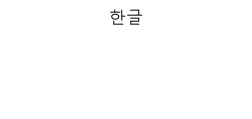

In [41]:
plt.figure(figsize=(3,1))
plt.title('한글')
plt.axis('off')
plt.show()

In [42]:
PATH = 'data/helmet'
IMG_DIR = os.path.join(PATH, 'images')
XML_DIR = os.path.join(PATH, 'annotations')

xml_files = sorted(
    os.path.join(XML_DIR, x) for x in os.listdir(XML_DIR) if x.endswith('.xml'))

print(len(xml_files))
print(xml_files[0])

5000
data/helmet\annotations\hard_hat_workers0.xml


In [43]:
import xml.etree.ElementTree as ET

def extract_info_from_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.find('filename').text
    for boxes in root.iter('object'):
        label = boxes.find('name').text
        if label=='head' or label=='person':
            return filename, 0
    return filename, 1

In [44]:
import cv2

img_data, label_data = [], []

t0 = time.time()
for xml_file in xml_files:
    filename, label = extract_info_from_xml(xml_file)

    img = cv2.imread(os.path.join(IMG_DIR, filename))
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_data.append(cv2.resize(img, (224, 224)))
    label_data.append(label)

img_data = np.array(img_data, dtype= np.uint8)
label_data= np.array(label_data, dtype=np.int64)

print(time.time())
print(img_data.shape, img_data.dtype, img_data.nbytes)
print(label_data.shape)

1788410477.8233676
(5000, 224, 224, 3) uint8 752640000
(5000,)


In [45]:
from collections import Counter

counter = Counter(label_data.tolist())
n_unsafe, n_safe = counter[0], counter[1]
print(f'0 위험: {n_unsafe} {n_unsafe/len(label_data)*100}')
print(f'1 안전: {n_safe} {n_safe/len(label_data)*100}')
print(f'불균형 비율 {max(n_unsafe, n_safe)/min(n_unsafe, n_safe):.2f}')


0 위험: 1060 21.2
1 안전: 3940 78.8
불균형 비율 3.72


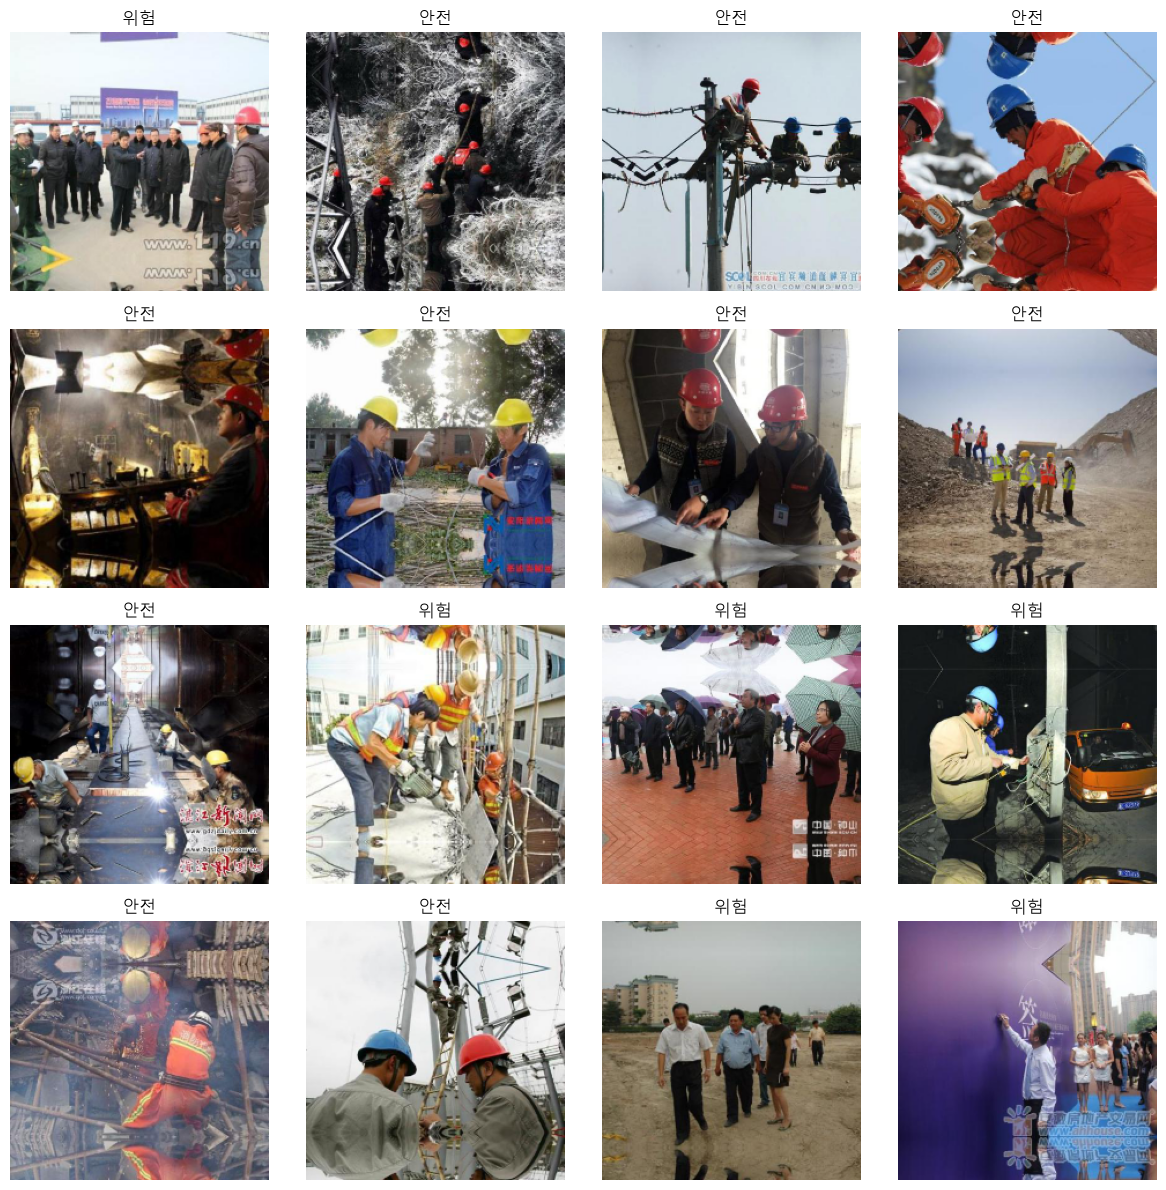

In [46]:
labels_to_names = {0: '위험',
                   1: '안전'}
plt.figure(figsize=(12, 12))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(img_data[i])
    plt.title(labels_to_names[label_data[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [47]:
from sklearn.model_selection import train_test_split

x_trainval, x_test, y_trainval, y_test = train_test_split(img_data, label_data,
                                                          test_size=0.1,
                                                          stratify=label_data,
                                                          random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_trainval, y_trainval,
                                                  test_size=0.2,
                                                  stratify=y_trainval,
                                                  random_state=42)
print(f'훈련: {len(x_train)}, 검증: {len(x_val)}, 테스트: {len(x_test)}')

훈련: 3600, 검증: 900, 테스트: 500


In [48]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

class HelmetDataset(Dataset):
    def __init__(self, images, labels, normalize='simple'):
        self.images = images
        self.labels = labels
        self.normalize = normalize

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32)/255.0

        if self.normalize == 'imagenet':
            img = (img - IMAGENET_MEAN) / IMAGENET_STD

        img = np.transpose(img, (2, 0, 1))

        return torch.from_numpy(img), torch.tensor(self.labels[idx], dtype = torch.float32)

def make_loader(normalize='simple', batch_size=32):
    tr = DataLoader(HelmetDataset(x_train, y_train, normalize),
                    batch_size=batch_size,
                    shuffle=True)
    va = DataLoader(HelmetDataset(x_val, y_val, normalize),
                    batch_size=batch_size,
                    shuffle=False)
    te = DataLoader(HelmetDataset(x_test, y_test, normalize),
                            batch_size=batch_size,
                            shuffle=False)
    return tr, va, te

_tr, _, _ = make_loader()
xb, yb = next(iter(_tr))
print(f'입력 배치: {tuple(xb.shape)} {xb.type}')
print(f'라벨 배치: {tuple(yb.shape)} {yb.type}')
print(f'범위: {xb.min():3f} ~ {xb.max():3f}')

입력 배치: (32, 3, 224, 224) <built-in method type of Tensor object at 0x000001F584443E30>
라벨 배치: (32,) <built-in method type of Tensor object at 0x000001F584443E80>
범위: 0.000000 ~ 1.000000


In [49]:
def conv_block(in_ch, out_ch):
    return [
        nn.Conv2d(in_ch, out_ch, kernel_size=3),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(out_ch)]

class BaseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            *conv_block(3, 64), *conv_block(64, 64), nn.MaxPool2d(2),
            *conv_block(64, 128), *conv_block(128, 128), nn.MaxPool2d(2),
            *conv_block(128, 256), *conv_block(256, 256), nn.MaxPool2d(2),
            *conv_block(256, 512), *conv_block(512, 512), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512 * 10 * 10, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 1))

    def forward(self, x):
        return self.classifier(self.features(x))

def summarize(model, name='model'):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    with torch.no_grad():
        out = model(torch.zeros(1, 3, 224, 224))
    print(name)
    print(f'출력 모양: {tuple(out.shape)}')
    print(f'전체 파라미터: {total:,}')
    print(f'학습 파라미터: {trainable:,}')
    print(f'고정 파라미터: {total - trainable:,}')

base_model = BaseCNN()
summarize(base_model, 'BaseCNN')

BaseCNN
출력 모양: (1, 1)
전체 파라미터: 57,120,065
학습 파라미터: 57,120,065
고정 파라미터: 0


In [59]:
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             roc_auc_score, confusion_matrix)

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    losses, probs, trues = [], [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb).squeeze(1)

        if criterion is not None:
            losses.append(criterion(logits, yb).item() * len(yb))

        probs.append(torch.sigmoid(logits).cpu().numpy())
        trues.append(yb.cpu().numpy())

    probs = np.concatenate(probs)
    trues = np.concatenate(trues)
    preds = (probs > 0.5).astype(int)

    return {
        'loss': ((sum(losses)) / (len(trues))) if criterion is not None else None,
        'accuracy': accuracy_score(trues, preds),
        'recall': recall_score(trues, preds, zero_division=0),
        'precision': precision_score(trues, preds, zero_division=0),
        'auc': roc_auc_score(trues, probs) if len(set(trues)) > 1 else float('nan'),
        'probs': probs,
        'trues': trues,
        'preds': preds}

def train_model(model, train_loader,
                val_loader, epochs=20,
                lr=1e-3, pos_weight=None,
                ckpt_path='best_model.pt',label='model'):
    model = model.to(device)
    pw = (None if pos_weight is None else torch.tensor([pos_weight],
                                                       dtype=torch.float32,
                                                       device=device))
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {k: [] for k in ['loss', 'val_loss', 'accuracy', 'val_accuracy',
                               'val_recall', 'val_precision', 'val_auc']}
    best_auc = -1.0

    for epoch in range(1, epochs+1):
        model.train()
        run_loss, run_correct, n = 0.0, 0, 0
        t0 = time.time()

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb).squeeze(1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * len(yb)
            run_correct += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
            n += len(yb)

        tr_loss, tr_acc = run_loss / n, run_correct / n

        m = evaluate(model, val_loader, criterion)

        history['loss'].append(tr_loss)
        history['accuracy'].append(tr_acc)
        history['val_loss'].append(m['loss'])
        history['val_accuracy'].append(m['accuracy'])
        history['val_recall'].append(m['recall'])
        history['val_precision'].append(m['precision'])
        history['val_auc'].append(m['auc'])

        star = ''
        if m['auc'] > best_auc:
            best_auc = m['auc']
            torch.save(model.state_dict(), ckpt_path)
            star = '저장'

        print(f'[{label}] {epoch:2d} / {epochs}'
              f'loss {tr_loss:4f} val_loss {m['loss']:4f}'
              f'val_acc {m['accuracy']:4f} val_auc {m['auc']:4f}'
              f'{time.time()-t0:4f} {star}')
    print(f'best val_auc = {best_auc:4f} {ckpt_path}')
    return history

In [64]:
import seaborn as sns

def plot_history(history, title):
    plt.figure(figsize=(6,4))
    plt.plot(history['loss'], label='train')
    plt.plot(history['val_loss'], label='val')
    plt.title(title)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(loc = 'upper left')
    plt.grid(alpha = 0.3)
    plt.tight_layout()
    plt.show()

def plot_confusion(model, loader, ckpt_path=None, title='혼동행렬'):
    if ckpt_path is not None:
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model = model.to(device)

    m = evaluate(model, loader)
    cm = confusion_matrix(m['trues'], m['preds'])

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True,
                fmt='d', cmap='Blues',
                annot_kws={'size': 16},
                xticklabels=['위험', '안전'],
                yticklabels=['위험', '안전'])
    plt.xlabel('예측값')
    plt.ylabel('실제값')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    print(f'정확도: {m['accuracy']:.4f} 재현율: {m['recall']:.4f}'
          f'정밀도: {m['precision']:.4f} AUC: {m['auc']:.4f}')
    return m

In [61]:
EPOCHS = 2

train_loader , val_loader, test_loader = make_loader(normalize='simple',
                                                     batch_size=32)
base_model = BaseCNN()
base_history = train_model(base_model, train_loader, val_loader,
                           epochs=EPOCHS, lr=1e-3,
                           ckpt_path = 'best_base_model.pt', label='model')

[model]  1 / 2loss 2.558300 val_loss 1.619202val_acc 0.776667 val_auc 0.582581336.064840 저장
[model]  2 / 2loss 0.943534 val_loss 0.913259val_acc 0.765556 val_auc 0.591560335.244274 저장
best val_auc = 0.591560 best_base_model.pt


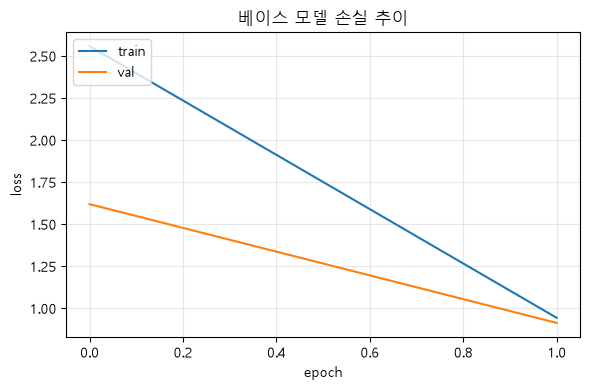

In [62]:
plot_history(base_history, '베이스 모델 손실 추이')

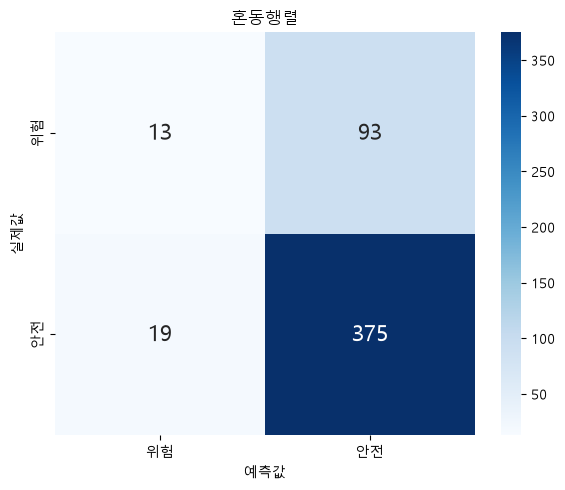

정확도: 0.7760 재현율: 0.9518정밀도: 0.8013 AUC: 0.6586


{'loss': None,
 'accuracy': 0.776,
 'recall': 0.9517766497461929,
 'precision': 0.8012820512820513,
 'auc': 0.6586174695910353,
 'probs': array([0.3904181 , 0.94708365, 0.99271977, 0.7021616 , 0.99450266,
        0.99992514, 0.7723126 , 0.9947673 , 0.9406683 , 0.8070326 ,
        1.        , 0.99985147, 0.45117304, 0.91749066, 0.87953967,
        0.6445725 , 0.5027794 , 0.50996387, 0.9977443 , 0.89416176,
        0.83136404, 0.9530333 , 0.99908507, 1.        , 0.7044996 ,
        0.9431433 , 0.4938585 , 1.        , 1.        , 0.99994516,
        0.890369  , 0.54441863, 0.8848674 , 0.9982759 , 0.70029163,
        0.6012149 , 0.9948796 , 0.8762601 , 0.99999964, 0.9767054 ,
        0.5804841 , 1.        , 0.9927288 , 0.9767774 , 0.98435855,
        0.67800355, 0.99999475, 0.6597717 , 0.64124763, 0.9932354 ,
        0.99681   , 0.79705334, 0.9332481 , 0.8733812 , 0.8263854 ,
        0.5998741 , 0.5393668 , 0.699653  , 0.54481965, 0.47195584,
        0.9992999 , 0.9694064 , 0.91685116, 0.9

In [65]:
plot_confusion(BaseCNN(), test_loader, ckpt_path = 'best_base_model.pt', title='혼동행렬')

In [66]:
from torchvision import models

class TransferModel(nn.Module):
    def __init__(self, freeze=True):
        super().__init__()
        weights = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
        backbone = models.efficientnet_v2_s(weights = weights)
        self.features = backbone.features

        if freeze:
            for p in self.features.parameters():
                p.requires_grad = False

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(1280, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.fc(self.dropout(x))

transfer_model = TransferModel(freeze=True)
summarize(transfer_model, 'TransferModel (EfficientNetV2-S 고정)')

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to C:\Users\KDS10/.cache\torch\hub\checkpoints\efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:01<00:00, 79.6MB/s]


TransferModel (EfficientNetV2-S 고정)
출력 모양: (1, 1)
전체 파라미터: 20,178,769
학습 파라미터: 1,281
고정 파라미터: 20,177,488


In [68]:
tr_loader, va_loader, te_loader = make_loader(normalize='imagenet',
                                              batch_size=32)
xb, _ = next(iter(tr_loader))
print(f'정규화범위: {xb.min():.3f} ~ {xb.max():.3f}')

정규화범위: -2.118 ~ 2.640


In [69]:
transfer_model = TransferModel(freeze=True)
transfer_history = train_model(transfer_model, tr_loader, va_loader,
                               epochs=EPOCHS, lr=5e-4,
                               ckpt_path='best_transfer_model.pt',
                               label='전이학습')

[전이학습]  1 / 2loss 0.524427 val_loss 0.484621val_acc 0.810000 val_auc 0.72599911.176585 저장
[전이학습]  2 / 2loss 0.463042 val_loss 0.461061val_acc 0.822222 val_auc 0.76635511.069924 저장
best val_auc = 0.766355 best_transfer_model.pt


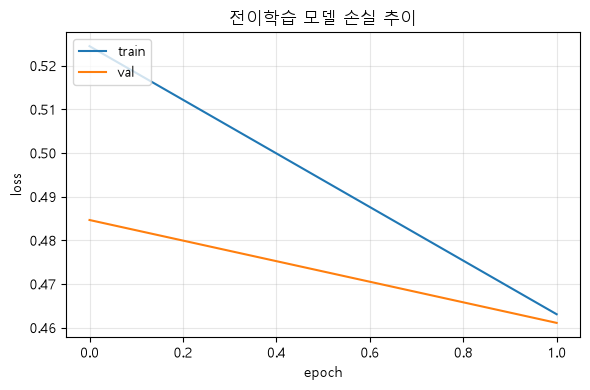

In [71]:
plot_history(transfer_history, '전이학습 모델 손실 추이')

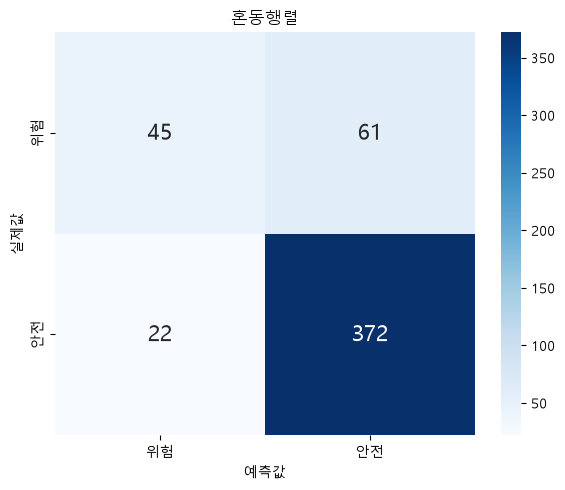

정확도: 0.8340 재현율: 0.9442정밀도: 0.8591 AUC: 0.7760


In [74]:
transfer_metrics = plot_confusion(TransferModel(freeze=True), te_loader,
                                  ckpt_path='best_transfer_model.pt',
                                  title='혼동행렬')

In [75]:
unsafe, safe = np.bincount(label_data)
total = unsafe + safe

weight_for_unsafe = (1 / unsafe) * (total / 2.0)
weight_for_safe = (1 / safe) * (total / 2.0)

pos_weight = weight_for_safe / weight_for_unsafe
print(pos_weight)

if pos_weight < 1:
    print('안전쪽에 벌점을 낮춘다')
else: 
    print('안전쪽에 벌점을 높인다')

0.26903553299492383
안전쪽에 벌점을 낮춘다


In [77]:
weighted_model = TransferModel(freeze=True)
weighted_history = train_model(weighted_model, tr_loader,
                               va_loader, epochs=EPOCHS,
                               lr=5e-4, pos_weight=pos_weight,
                               ckpt_path='best_transfer_model.pt',
                               label='가중치적용')

[가중치적용]  1 / 2loss 0.272522 val_loss 0.254469val_acc 0.690000 val_auc 0.78283310.128190 저장
[가중치적용]  2 / 2loss 0.246440 val_loss 0.241429val_acc 0.717778 val_auc 0.79480710.124085 저장
best val_auc = 0.794807 best_transfer_model.pt


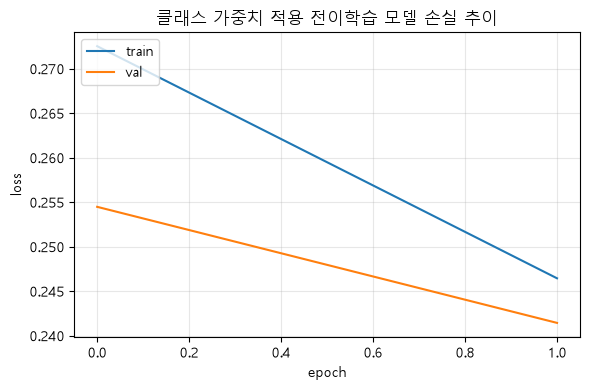

In [78]:
plot_history(weighted_history, '클래스 가중치 적용 전이학습 모델 손실 추이')

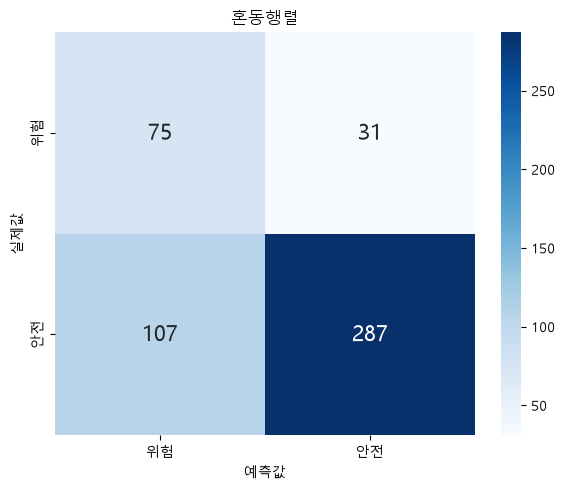

정확도: 0.7240 재현율: 0.7284정밀도: 0.9025 AUC: 0.8039


In [79]:
weighted_metrics = plot_confusion(TransferModel(freeze=True), te_loader,
                                  ckpt_path='best_transfer_model.pt',
                                  title='혼동행렬')